In [1]:
import os
import pandas as pd
import numpy as np
import src.feedbackFunctions as ff

In [2]:
# Settings
data_dir = '/DATAPOOL/VPMB/BIDS-VPMB-SPE'
fmriprep_dir = os.path.join(data_dir,'derivatives','fmriprep23','fmriprep')
nilearn_dir = os.path.join(data_dir,'derivatives','nilearn_glm')
output_dir = os.path.join(data_dir,'derivatives','feedbackSimulator')

subject_list = [x for x in os.listdir(data_dir) if 'sub-' in x]
subject_list.sort()

tr_list = [0.5, 0.75, 1, 2.5]
n_volumes_list = [780, 520, 390, 156]
run_list = ['AA','UA']
hrf_delay = 3 # in seconds

In [3]:
# Load subject-specific roi coordinates
roi_ss_coords = pd.read_csv(os.path.join(nilearn_dir,'group','roi_ss_matrix.txt'), sep='\t', header=None,
                            names=['left_x','left_y','left_z','right_x','right_y','right_z'])

# add new column with the subject names
roi_ss_coords['subject'] = subject_list
labels = ['hMT+ L', 'hMT+ R']

In [4]:
# Initialize matrix to store the timeseries of all subjects per tr
TC = np.zeros((len(subject_list), len(tr_list), len(run_list), max(n_volumes_list)))

In [5]:
# Create combinations of subject, tr and run
C = []
for ss,subject in enumerate(subject_list):
    # extract x,y,z coordinates of this subject's hMT+ roi
    cluster_coords = [[0, 0, 0], [0, 0, 0]]
    cluster_coords[0] = roi_ss_coords[roi_ss_coords['subject']==subject].iloc[:,0:3].values[0].tolist()
    cluster_coords[1] = roi_ss_coords[roi_ss_coords['subject']==subject].iloc[:,3:6].values[0].tolist()

    for tt,tr in enumerate(tr_list):
        for rr,run in enumerate(run_list):
            C.append([subject, tr, run, cluster_coords, fmriprep_dir, data_dir])

C

[['sub-01',
  0.5,
  'AA',
  [[-46, -70, 12], [46, -76, 6]],
  '/DATAPOOL/VPMB/BIDS-VPMB-SPE/derivatives/fmriprep23/fmriprep',
  '/DATAPOOL/VPMB/BIDS-VPMB-SPE'],
 ['sub-01',
  0.5,
  'UA',
  [[-46, -70, 12], [46, -76, 6]],
  '/DATAPOOL/VPMB/BIDS-VPMB-SPE/derivatives/fmriprep23/fmriprep',
  '/DATAPOOL/VPMB/BIDS-VPMB-SPE'],
 ['sub-01',
  0.75,
  'AA',
  [[-46, -70, 12], [46, -76, 6]],
  '/DATAPOOL/VPMB/BIDS-VPMB-SPE/derivatives/fmriprep23/fmriprep',
  '/DATAPOOL/VPMB/BIDS-VPMB-SPE'],
 ['sub-01',
  0.75,
  'UA',
  [[-46, -70, 12], [46, -76, 6]],
  '/DATAPOOL/VPMB/BIDS-VPMB-SPE/derivatives/fmriprep23/fmriprep',
  '/DATAPOOL/VPMB/BIDS-VPMB-SPE'],
 ['sub-01',
  1,
  'AA',
  [[-46, -70, 12], [46, -76, 6]],
  '/DATAPOOL/VPMB/BIDS-VPMB-SPE/derivatives/fmriprep23/fmriprep',
  '/DATAPOOL/VPMB/BIDS-VPMB-SPE'],
 ['sub-01',
  1,
  'UA',
  [[-46, -70, 12], [46, -76, 6]],
  '/DATAPOOL/VPMB/BIDS-VPMB-SPE/derivatives/fmriprep23/fmriprep',
  '/DATAPOOL/VPMB/BIDS-VPMB-SPE'],
 ['sub-01',
  2.5,
  'AA',
  [

In [6]:
# open parallel pool and execute
from multiprocessing import Pool
pool = Pool(20)

results = pool.starmap(ff.execute,C)
pool.close()

sub-01_0.75_AAsub-01_1_AAsub-01_0.5_AAsub-01_2.5_AAsub-02_0.5_AAsub-02_0.75_AAsub-02_1_AAsub-02_2.5_AAsub-03_0.5_AAsub-03_0.75_AAsub-03_1_AA

sub-03_2.5_AAsub-05_0.5_AA

sub-05_0.75_AAsub-05_1_AA
sub-05_2.5_AA

sub-06_0.5_AA
sub-06_0.75_AAsub-06_1_AA
sub-06_2.5_AA










Extracting timeseries for sub-01 with bandpass, zscore, and detrendExtracting timeseries for sub-02 with bandpass, zscore, and detrend
Extracting timeseries for sub-03 with bandpass, zscore, and detrend

Extracting timeseries for sub-06 with bandpass, zscore, and detrend
Extracting timeseries for sub-05 with bandpass, zscore, and detrend
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/DATAPOOL/VPMB/BIDS-VPMB-SPE/derivatives/fmriprep23/fmriprep/sub-01/func/sub-01_task-AA_acq-2500_run-1_space-MNI152NLin2009cAsym_res-2_desc-preproc_bold.nii.gz', 
{ 'allow_overlap': False,
  'clean_kwargs': {'butter

/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/signal.py:299: UserWarning: The frequency specified for the low pass filter is too high to be handled by a digital filter (superior to Nyquist frequency). It has been lowered to 0.19999999999999957 (Nyquist frequency).
  warnings.warn(
/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/joblib/memory.py:349: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.13, the default strategy will be replaced by the new strategy and the 'zscore' option will be removed. Please use 'zscore_sample' instead.
  return self.func(*args, **kwargs)


______________________________________________filter_and_extract - 38.0s, 0.6min
sub-05_2.5_UA
Extracting timeseries for sub-05 with bandpass, zscore, and detrend
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/DATAPOOL/VPMB/BIDS-VPMB-SPE/derivatives/fmriprep23/fmriprep/sub-05/func/sub-05_task-UA_acq-2500_run-1_space-MNI152NLin2009cAsym_res-2_desc-preproc_bold.nii.gz', 
{ 'allow_overlap': False,
  'clean_kwargs': {'butterworth__padtype': 'even'},
  'detrend': True,
  'dtype': None,
  'high_pass': 0.003,
  'high_variance_confounds': False,
  'low_pass': 1,
  'mask_img': None,
  'radius': 6,
  'seeds': [[-46, -70, 8], [48, -64, 6]],
  'smoothing_fwhm': None,
  'standardize': 'zscore_sample',
  'standardize_confounds': True,
  't_r': 2.5}, confounds=[               csf  csf_derivative1    csf_power2  csf_derivative1_power2  \
0    12784.779831         0.000000  1.6345

/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/signal.py:299: UserWarning: The frequency specified for the low pass filter is too high to be handled by a digital filter (superior to Nyquist frequency). It has been lowered to 0.19999999999999957 (Nyquist frequency).
  warnings.warn(
/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/joblib/memory.py:349: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.13, the default strategy will be replaced by the new strategy and the 'zscore' option will be removed. Please use 'zscore_sample' instead.
  return self.func(*args, **kwargs)


______________________________________________filter_and_extract - 40.6s, 0.7min
sub-06_2.5_UA
Extracting timeseries for sub-06 with bandpass, zscore, and detrend
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/DATAPOOL/VPMB/BIDS-VPMB-SPE/derivatives/fmriprep23/fmriprep/sub-06/func/sub-06_task-UA_acq-2500_run-1_space-MNI152NLin2009cAsym_res-2_desc-preproc_bold.nii.gz', 
{ 'allow_overlap': False,
  'clean_kwargs': {'butterworth__padtype': 'even'},
  'detrend': True,
  'dtype': None,
  'high_pass': 0.003,
  'high_variance_confounds': False,
  'low_pass': 1,
  'mask_img': None,
  'radius': 6,
  'seeds': [[-46, -66, 12], [48, -68, 6]],
  'smoothing_fwhm': None,
  'standardize': 'zscore_sample',
  'standardize_confounds': True,
  't_r': 2.5}, confounds=[               csf  csf_derivative1    csf_power2  csf_derivative1_power2  \
0    11626.117173         0.000000  1.351

...

______________________________________________filter_and_extract - 90.1s, 1.5min
[NiftiSpheresMasker.transform_single_imgs] Cleaning extracted signals


/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/signal.py:299: UserWarning: The frequency specified for the low pass filter is too high to be handled by a digital filter (superior to Nyquist frequency). It has been lowered to 0.9999999999999978 (Nyquist frequency).
  warnings.warn(
/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/joblib/memory.py:349: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.13, the default strategy will be replaced by the new strategy and the 'zscore' option will be removed. Please use 'zscore_sample' instead.
  return self.func(*args, **kwargs)


_____________________________________________filter_and_extract - 102.4s, 1.7min
[NiftiSpheresMasker.transform_single_imgs] Cleaning extracted signals


/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/signal.py:299: UserWarning: The frequency specified for the low pass filter is too high to be handled by a digital filter (superior to Nyquist frequency). It has been lowered to 0.9999999999999978 (Nyquist frequency).
  warnings.warn(
/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/joblib/memory.py:349: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.13, the default strategy will be replaced by the new strategy and the 'zscore' option will be removed. Please use 'zscore_sample' instead.
  return self.func(*args, **kwargs)


_____________________________________________filter_and_extract - 102.5s, 1.7min


In [7]:
# create dataframe based on results
df = pd.DataFrame(results)

df['subject'] = [x[0] for x in C]
df['tr'] = [x[1] for x in C]
df['run'] = [x[2] for x in C]

# save dataframe
df.to_csv(os.path.join(output_dir,'feedbackSimulator.tsv'), index=False, sep='\t')
#df.iloc[:,0:10].mean(axis=0)


# Load from here

In [8]:
# load dataframe
df = pd.read_csv(os.path.join(output_dir,'feedbackSimulator.tsv'), sep='\t')
df

,0,1,2,3,4,5,6,7,8,9,...,773,774,775,776,777,778,779,subject,tr,run
0,0.627503,0.198726,0.393851,2.692636,1.364537,0.298442,0.816172,1.098529,2.071771,3.057360,...,-0.593027,1.289627,-0.650719,-2.976604,-0.539522,-1.573916,-1.500727,sub-01,0.50,AA
1,1.121866,0.263034,-1.561224,-1.069070,-0.765155,-0.412093,0.334806,2.379552,1.847220,-1.742158,...,0.320259,0.312954,-0.564585,-0.245429,-0.230845,-1.014568,-1.523844,sub-01,0.50,UA
2,-0.944503,0.208292,0.078522,0.071528,0.264946,-0.198315,-0.164351,-1.312059,-0.981591,0.021801,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sub-01,0.75,AA
3,-0.089798,-0.305255,1.257203,0.822606,0.923849,1.347662,0.591007,0.766286,-0.216686,0.530250,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sub-01,0.75,UA
4,0.388064,0.764537,-0.141660,0.407203,0.204026,0.743402,0.620596,1.162767,1.424546,0.431726,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sub-01,1.00,AA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,0.369477,0.728358,0.300979,-0.059951,-0.158832,0.721426,0.710386,-0.463830,-1.496934,-0.829455,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sub-23,0.75,UA
116,-0.066877,0.630544,0.576991,0.122902,0.859925,1.377044,1.080996,-0.690087,-0.171077,0.215199,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sub-23,1.00,AA
117,0.478953,0.684923,-1.131249,-1.612566,-0.302008,-0.234489,0.959378,-0.065136,-0.684709,-0.565721,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sub-23,1.00,UA
118,-0.808874,-0.303451,-0.594465,-0.482650,-0.324907,1.243492,-0.849840,0.274154,-0.533788,-0.751374,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sub-23,2.50,AA


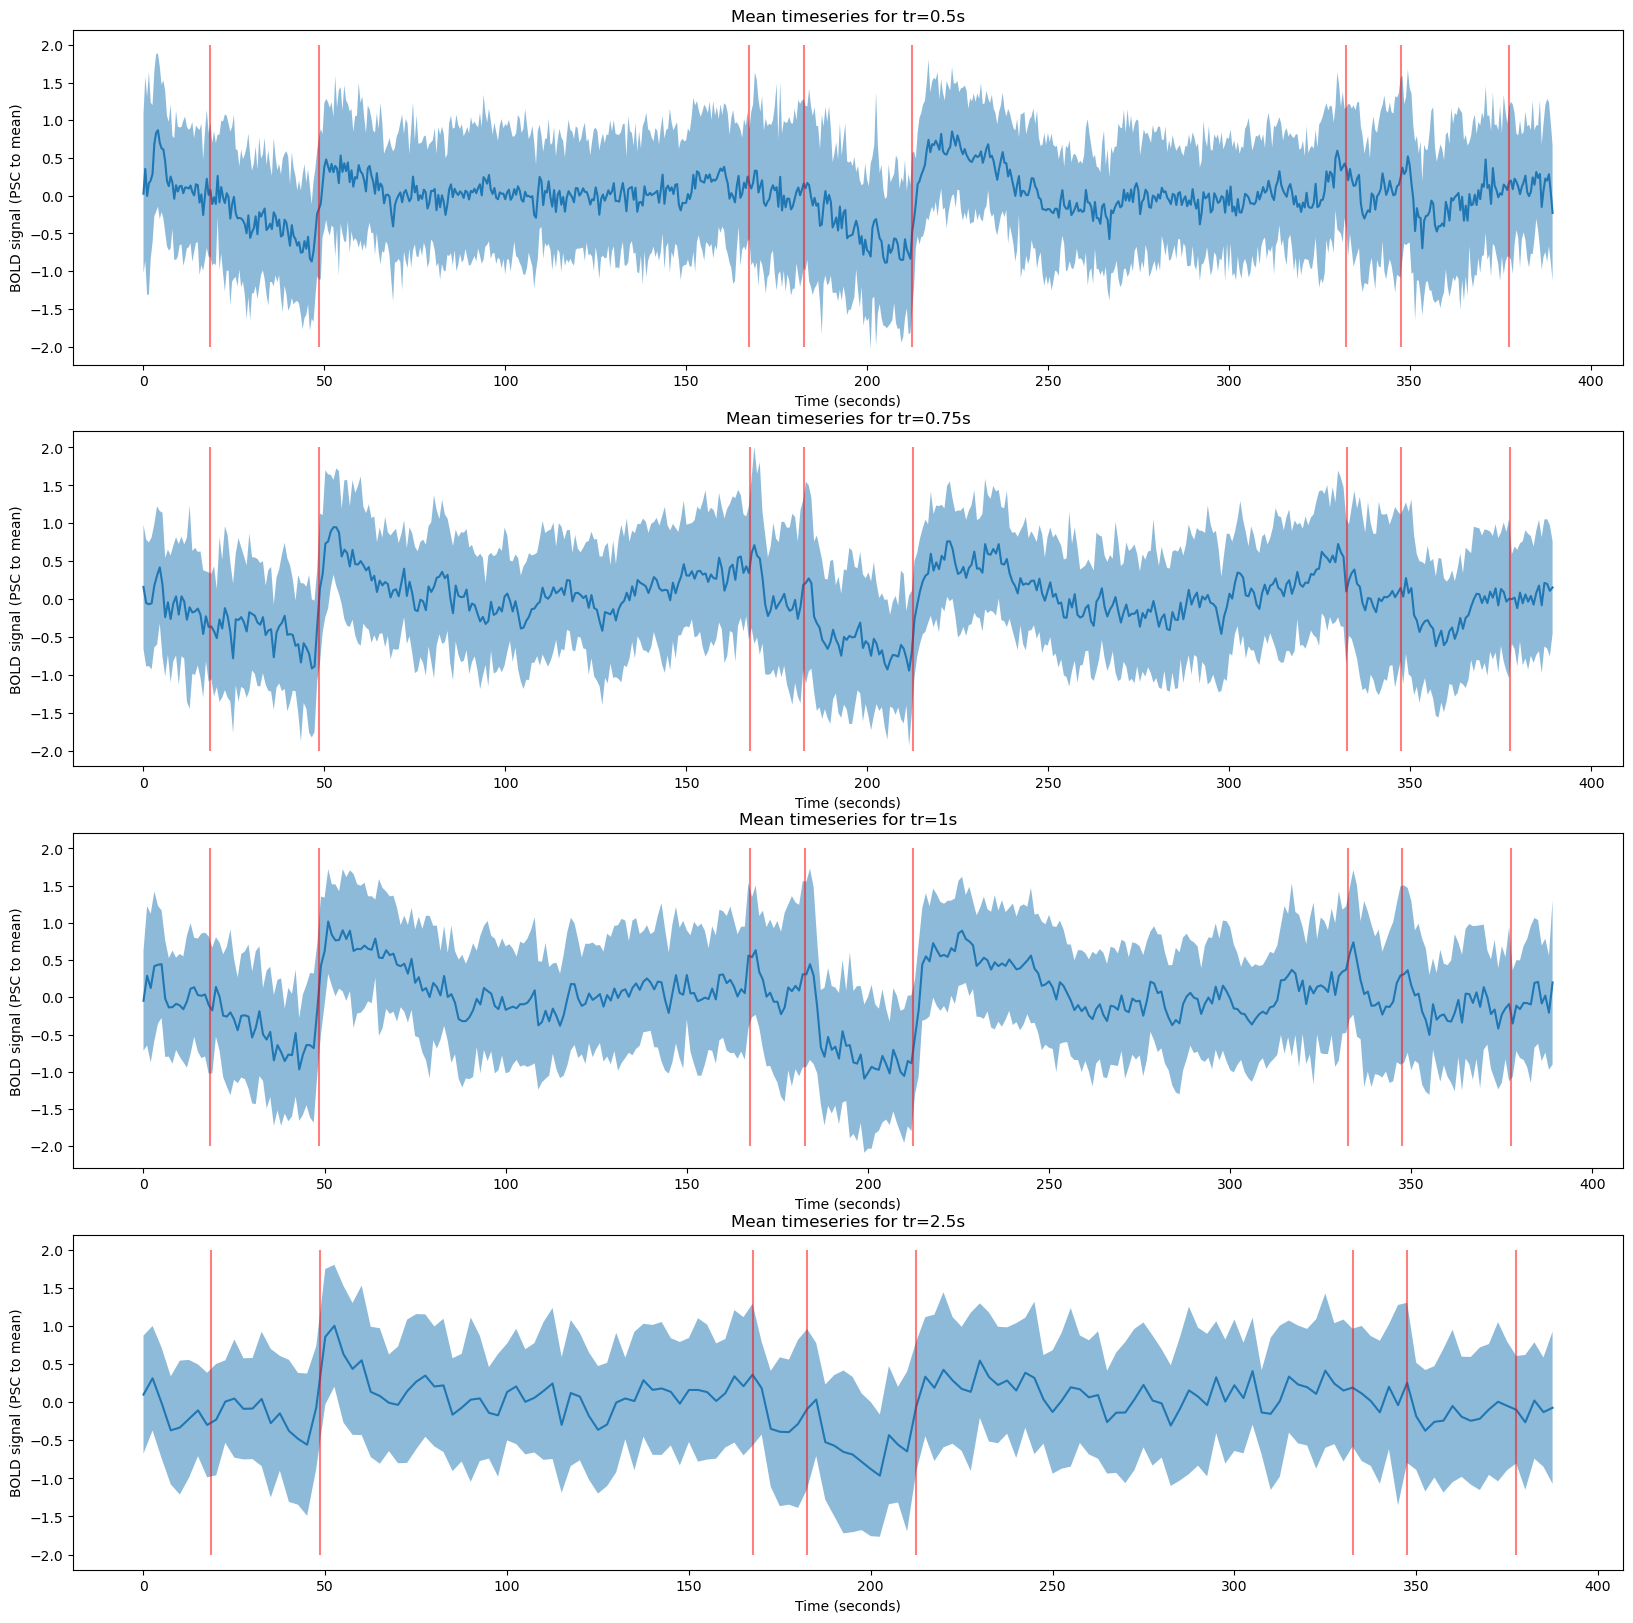

In [11]:
import matplotlib.pyplot as plt

verticalMarkers = np.array([15.5,45.5,164.5,179.5,209.5,329.5,344.5,374.5]) + hrf_delay # these mark the change of condition (including hrf_delay)

# plot mean timeseries for each tr
f, axs = plt.subplots(4, 1, figsize=(20, 20))

for tr_idx,tr in enumerate(tr_list):
    
    # create time vector based on the number of time points and the tr
    time_vector = np.arange(0, n_volumes_list[tr_idx]*tr, tr)

    # plot mean and std timeseries
    data_to_plot_mean = df[df['tr']==tr].iloc[:,0:n_volumes_list[tr_idx]].mean(axis=0)
    data_to_plot_std = df[df['tr']==tr].iloc[:,0:n_volumes_list[tr_idx]].std(axis=0)

    axs[tr_idx].plot(time_vector, data_to_plot_mean)
    axs[tr_idx].fill_between(time_vector, data_to_plot_mean-data_to_plot_std, data_to_plot_mean+data_to_plot_std, alpha=0.5)
    axs[tr_idx].vlines(verticalMarkers, ymin=-2, ymax=2, color='red', alpha=0.5)
    axs[tr_idx].set_title('Mean timeseries for tr='+str(tr)+'s')
    axs[tr_idx].set_xlabel('Time (seconds)')
    axs[tr_idx].set_ylabel('BOLD signal (zscore)')

## Events file and PSC to static

In [12]:
# Load sample events file per TR for sub-01
run_type = 'UA'
active_cond_name = 'Ambiguous' if run_type=='AA' else 'Unambiguous'

static_events_indexes_arr = np.zeros((len(tr_list), 500))
active_events_indexes_arr = np.zeros((len(tr_list), 500))

for tr_idx,tr in enumerate(tr_list):

    task_label = f'task-{run_type}_acq-{round(tr*1000):04}_run-1'
    events_file = os.path.join(data_dir, 'sub-01', 'func', f'sub-01_{task_label}_events.tsv')

    static_events_indexes, active_events_indexes = ff.read_events(events_file,hrf_delay,tr,active_cond_name)

    # save to array
    static_events_indexes_arr[tr_idx,:len(static_events_indexes)] = static_events_indexes
    active_events_indexes_arr[tr_idx,:len(active_events_indexes)] = active_events_indexes

verticalMarkers = np.array([15.5,45.5,164.5,179.5,209.5,329.5,344.5,374.5]) + hrf_delay # these mark the change of condition (including hrf_delay)

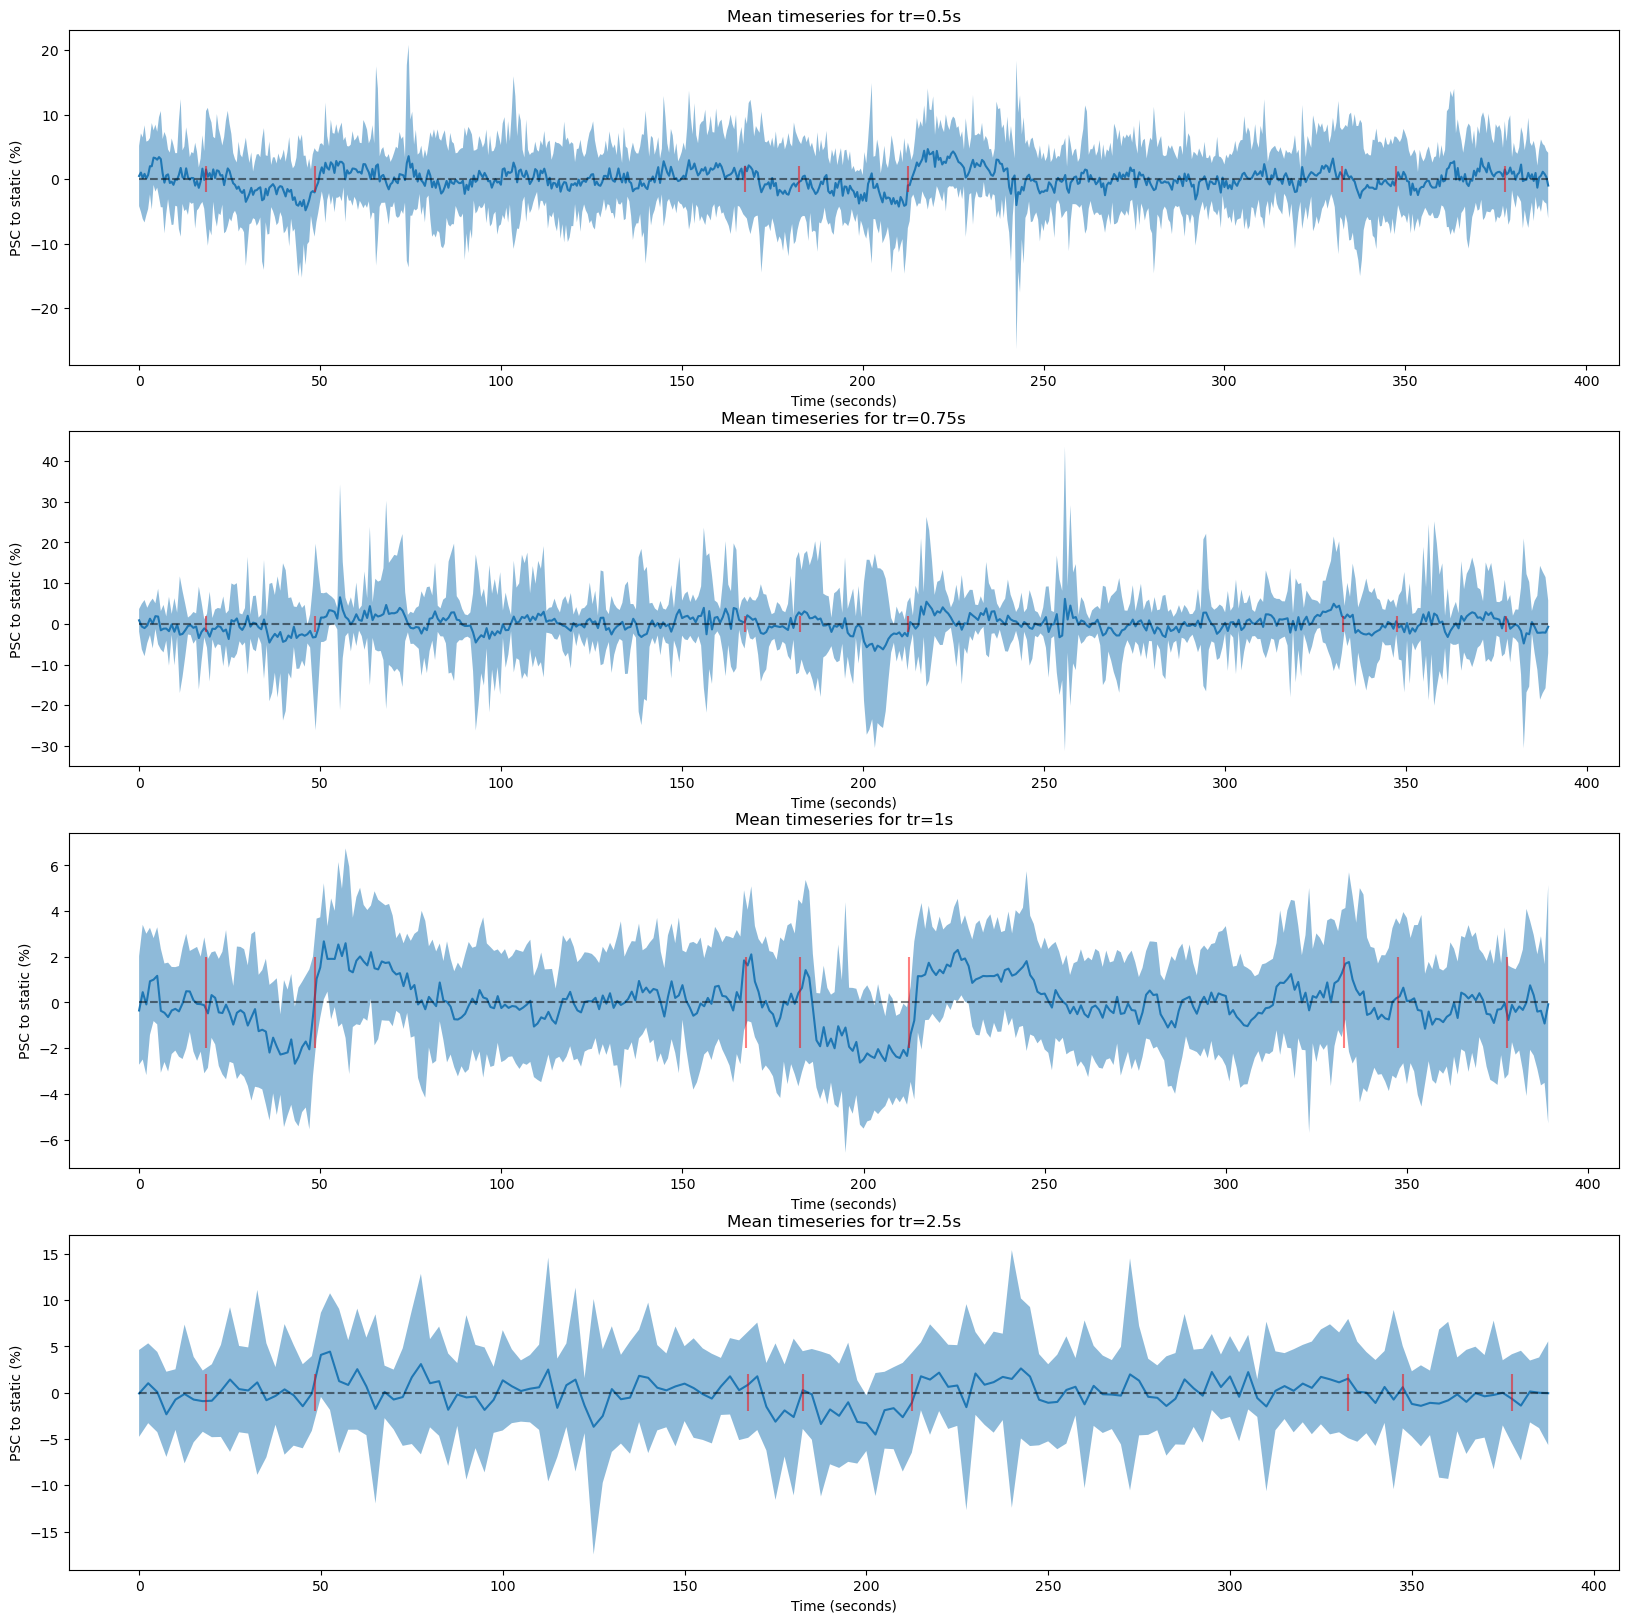

In [13]:
# plot mean PSC to static timeseries for each tr
f_psc, axs_psc = plt.subplots(4, 1, figsize=(20, 20))

for tr_idx,tr in enumerate(tr_list):

    # extract static_events_indexes for each tr excluding zeros
    static_events_indexes_aux = static_events_indexes_arr[tr_idx,static_events_indexes_arr[tr_idx,:] > 0]
    
    time_series = df[df['tr']==tr].iloc[:,0:n_volumes_list[tr_idx]]
    time_series_static = time_series.iloc[:,static_events_indexes_aux.astype(int)]

    # calculate mean of each row
    m = time_series_static.mean(axis=1)

    # substrat m from time_series and divide by abs(m)
    time_series_psc = time_series.divide(abs(m), axis=0)

    time_series_mean = time_series_psc.mean(axis=0)
    time_series_std = time_series_psc.std(axis=0)
    
    # create time vector based on the number of time points and the tr
    time_vector = np.arange(0, n_volumes_list[tr_idx]*tr, tr)

    # plot mean and std timeseries
    axs_psc[tr_idx].plot(time_vector, time_series_mean)
    axs_psc[tr_idx].fill_between(time_vector, time_series_mean-time_series_std, time_series_mean+time_series_std, alpha=0.5)
    axs_psc[tr_idx].vlines(verticalMarkers, ymin=-2, ymax=2, color='red', alpha=0.5)
    axs_psc[tr_idx].hlines(0, xmin=0, xmax=time_vector[-1], color='black', alpha=0.5, linestyle='--')
    axs_psc[tr_idx].set_title('Mean timeseries for tr='+str(tr)+'s')
    #axs_psc[tr_idx].set_ylim([-5, 20])
    axs_psc[tr_idx].set_xlabel('Time (seconds)')
    axs_psc[tr_idx].set_ylabel('PSC to static (%)')

In [ ]:
# plot ERA with mean PSC to static timeseries for each tr
f_psc, axs_psc = plt.subplots(4, 1, figsize=(20, 20))

for tr_idx,tr in enumerate(tr_list):

    # extract static_events_indexes for each tr excluding zeros
    static_events_indexes_aux = static_events_indexes_arr[tr_idx,static_events_indexes_arr[tr_idx,:] > 0]
    active_events_indexes_aux = active_events_indexes_arr[tr_idx,active_events_indexes_arr[tr_idx,:] > 0]

    time_series = df[df['tr']==tr].iloc[:,0:n_volumes_list[tr_idx]]
    time_series_static = time_series.iloc[:,static_events_indexes_aux.astype(int)]
    m = time_series_static.mean(axis=1)

    # substrat m from time_series and divide by abs(m)
    time_series_psc = time_series.subtract(m, axis=0).divide(abs(m), axis=0)

    time_series_mean = time_series_psc.mean(axis=0)
    time_series_std = time_series_psc.std(axis=0)

    # estimate event related response
    time_series_mean_active = time_series_mean[active_events_indexes_aux.astype(int)]
    time_series_mean_active_length = time_series_mean_active.shape[0]//2

    # reshape time_series_mean_active to two columns with half the points each
    time_series_mean_active = time_series_mean_active.values.reshape((2,time_series_mean_active_length)).T

    # estimate mean and std
    time_series_mean_psc_active_mean = time_series_mean_active.mean(axis=1)
    time_series_mean_psc_active_std = time_series_mean_active.std(axis=1)

    # create time vector based on the number of time points and the tr
    time_vector = np.arange(0, time_series_mean_active_length*tr, tr)

    data_to_plot_mean = time_series_mean_psc_active_mean
    data_to_plot_std = time_series_mean_psc_active_std

    # plot mean and std timeseries
    axs_psc[tr_idx].plot(time_vector, data_to_plot_mean)
    axs_psc[tr_idx].fill_between(time_vector, data_to_plot_mean-data_to_plot_std, data_to_plot_mean+data_to_plot_std, alpha=0.5)
    axs_psc[tr_idx].hlines(0, 0, time_vector[-1], colors='k', linestyles='dashed')
    axs_psc[tr_idx].set_title('Mean timeseries during AA and UA blocks for tr='+str(tr)+'s')
    axs_psc[tr_idx].set_xlabel('Time (seconds)')
    axs_psc[tr_idx].set_ylabel('PSC to static (%)')
    #axs_psc[tr_idx].set_ylim([-1, 8])

In [ ]:
# plot feedback signal ERA with mean PSC to static timeseries for each tr
max_psc = 3
f_psc, axs_psc = plt.subplots(4, 1, figsize=(20, 20))
f_feedback, axs_feedback = plt.subplots(figsize=(20, 5))

for tr_idx,tr in enumerate(tr_list):

    # extract static_events_indexes for each tr excluding zeros
    static_events_indexes_aux = static_events_indexes_arr[tr_idx,static_events_indexes_arr[tr_idx,:] > 0]
    active_events_indexes_aux = active_events_indexes_arr[tr_idx,active_events_indexes_arr[tr_idx,:] > 0]

    time_series = df[df['tr']==tr].iloc[:,0:n_volumes_list[tr_idx]]
    time_series_static = time_series.iloc[:,static_events_indexes_aux.astype(int)]
    m = time_series_static.mean(axis=1)

    # substrat m from time_series and divide by abs(m)
    time_series_psc = time_series.subtract(m, axis=0).divide(abs(m), axis=0)

    # remap time_series_psc to feedback signal, limiting the max value to max_psc and the min value to 0
    time_series_psc_remap = time_series_psc.multiply(max_psc, axis=0).divide(max_psc, axis=0)
    time_series_psc_remap[time_series_psc_remap > max_psc] = max_psc
    time_series_psc_remap[time_series_psc_remap < 0] = 0

    time_series_mean = time_series_psc.mean(axis=0)
    time_series_std = time_series_psc.std(axis=0)

    time_series_remap_mean = time_series_psc_remap.mean(axis=0)
    time_series_remap_std = time_series_psc_remap.std(axis=0)

    # estimate event related response
    time_series_mean_active = time_series_mean[active_events_indexes_aux.astype(int)]
    time_series_remap_mean_active = time_series_remap_mean[active_events_indexes_aux.astype(int)]
    time_series_mean_active_length = time_series_mean_active.shape[0]//2

    # reshape time_series_mean_active to two columns with half the points each
    time_series_mean_active = time_series_mean_active.values.reshape((2,time_series_mean_active_length)).T
    time_series_remap_mean_active = time_series_remap_mean_active.values.reshape((2,time_series_mean_active_length)).T

    # estimate mean and std
    time_series_mean_psc_active_mean = time_series_mean_active.mean(axis=1)
    time_series_mean_psc_active_std = time_series_mean_active.std(axis=1)

    time_series_remap_mean_psc_active_mean = time_series_remap_mean_active.mean(axis=1)
    time_series_remap_mean_psc_active_std = time_series_remap_mean_active.std(axis=1)

    # create time vector based on the number of time points and the tr
    time_vector = np.arange(0, time_series_mean_active_length*tr, tr)

    data_to_plot_std = time_series_mean_psc_active_std

    # plot mean and std timeseries
    axs_psc[tr_idx].plot(time_vector, time_series_mean_psc_active_mean)
    axs_psc[tr_idx].plot(time_vector, time_series_remap_mean_psc_active_mean, linestyle='', marker='o')
    axs_psc[tr_idx].hlines(max_psc, 0, time_vector[-1], colors='g', linestyles='dashed', alpha=0.25)
    #axs_psc[tr_idx].hlines(-max_psc, 0, time_vector[-1], colors='g', linestyles='dashed', alpha=0.25)
    axs_psc[tr_idx].fill_between(time_vector, time_series_mean_psc_active_mean-time_series_mean_psc_active_std, time_series_mean_psc_active_mean+time_series_mean_psc_active_std, alpha=0.5)
    axs_psc[tr_idx].set_title('Mean timeseries during AA and UA blocks for tr='+str(tr)+'s')
    axs_psc[tr_idx].set_xlabel('Time (seconds)')
    axs_psc[tr_idx].set_ylabel('PSC to static (%)')
    axs_psc[tr_idx].set_ylim([-1, max_psc+2])
    axs_psc[tr_idx].legend(['original','feedback', 'maxPSC'])

    # plot feedback signal for this tr in figure_feedback
    axs_feedback.plot(time_vector, time_series_remap_mean_psc_active_mean, linestyle='-', marker='o')

axs_feedback.hlines(0, 0, time_vector[-1], colors='g', linestyles='dashed', alpha=0.25)
axs_feedback.set_ylim([-4, max_psc+2])
axs_feedback.legend(['tr='+str(tr)+'s' for tr in tr_list],loc='upper right')
axs_feedback.set_title('Feedback signal for each tr')
axs_feedback.set_xlabel('Time (seconds)')
axs_feedback.set_ylabel('Feedback signal')